In [26]:
import pandas as pd
import sqlite3

In [27]:
try:
  connect = sqlite3.connect('data/checking-logs.sqlite')
  print('OK. Connected to sqlite')

except sqlite3.Error as error:
  print('Error with connection:', error)

OK. Connected to sqlite


In [41]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits['weekday'] = commits['timestamp'].dt.dayofweek
commits['day'] = commits.timestamp.dt.day
commits['hour'] = commits.timestamp.dt.hour
commits['type'] = commits['weekday'].apply(
    lambda x: 'workind_day' if x < 5 else 'weekend'
)
commits = commits.drop(columns = ['weekday'])
commits

,uid,timestamp,day,hour,type
0,user_4,2020-04-17 05:19:02.744528,17,5,workind_day
1,user_4,2020-04-17 05:22:35.249331,17,5,workind_day
2,user_4,2020-04-17 05:22:45.549397,17,5,workind_day
3,user_4,2020-04-17 05:34:14.691200,17,5,workind_day
4,user_4,2020-04-17 05:34:24.422370,17,5,workind_day
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,21,20,workind_day
3203,user_1,2020-05-21 20:22:41.785725,21,20,workind_day
3204,user_1,2020-05-21 20:22:41.877806,21,20,workind_day
3205,user_1,2020-05-21 20:37:00.129678,21,20,workind_day


In [ ]:
'''
Для каждого часа рассчитаем среднее количество коммитов в 
рабочие дни и в выходные дни
'''

In [47]:
avg_comits = commits.groupby(['type','hour','day']).count()
avg_comits

uid  timestamp
type        hour day                
weekend     0    10     2          2
                 19     2          2
                 26     2          2
            1    10     6          6
            3    25     1          1
...                   ...        ...
workind_day 22   24     2          2
                 29     6          6
            23   11     4          4
                 13     8          8
                 20     3          3

[282 rows x 2 columns]

In [48]:
avg_comits  = avg_comits.groupby(['type','hour']).mean()['uid'].reset_index()
avg_comits

,type,hour,uid
0,weekend,0,2.000000
1,weekend,1,6.000000
2,weekend,3,1.000000
3,weekend,5,2.000000
4,weekend,7,4.000000
5,weekend,8,7.000000
6,weekend,9,3.666667
7,weekend,10,7.000000
8,weekend,11,23.600000
9,weekend,12,9.500000


In [ ]:
##Создаем сводную таблицу

In [49]:
pivot_table = pd.pivot(avg_comits,
                    values = 'uid',
                    index = 'hour',
                    columns = 'type')
pivot_table

type,weekend,workind_day
hour,,
0,2.000000,3.000000
1,6.000000,NaN
3,1.000000,2.000000
5,2.000000,7.500000
6,NaN,1.500000
7,4.000000,5.166667
8,7.000000,3.700000
9,3.666667,6.000000
10,7.000000,13.200000


array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'workind_day'}, xlabel='hour'>],
      dtype=object)

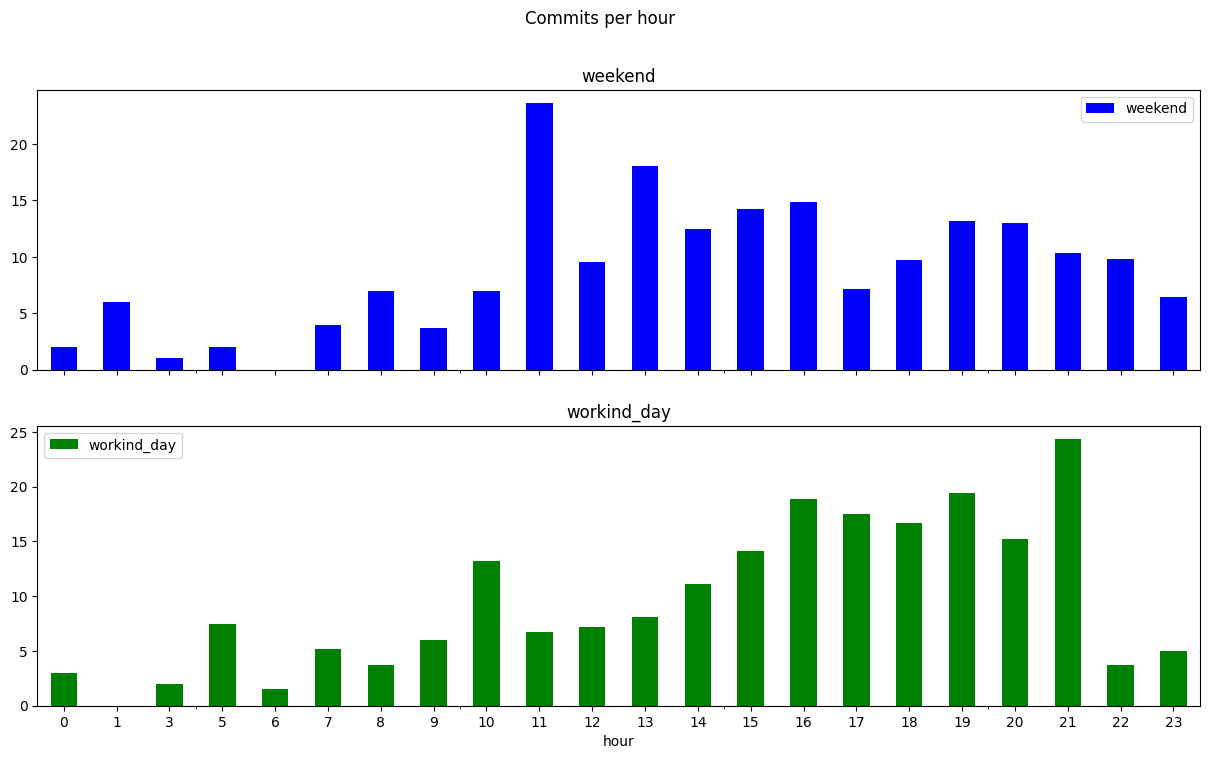

In [61]:
pivot_table.plot(
    kind = 'bar',
    figsize=(15,8),
    fontsize=10,
    title='Commits per hour',
    rot=0,
    subplots = True,
    color=('blue','green'))

In [ ]:
## “Is the dynamic different on working days and weekends?
'''
Да отличаеться,наибольшее число коммитов в выходные в 11 часов,
наибольшее число коммитов в рабочий день в 21 часа
'''

In [28]:
connect.close()